<a href="https://colab.research.google.com/github/espoirgk/PhD_Repos/blob/main/Rain_indices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Calculate some indices for rain for crujra_twodeg_v2.1_1901_2019 dataset

*   Rainfall Sum (mm)
*   Maximum Rainfall (mm/day)
*   Annual Average (mm/day)
*   Standard Deviation (mm/day)
*   Rainy Days Count
*   First Day of Rain
*   Second Rainy Day
*   Day Before Last Rainy Day
*   Last Rainy Day
*   Total day between last and first rainy season day
*   Total day between before-last and first rainy season day


In [ ]:
import pandas as pd

weather = pd.read_csv("crujra_twodeg_v2.1_1901_2019.csv", encoding= 'unicode_escape')
weather['time'] = pd.to_datetime(weather['time'])
weather = weather.set_index("time")

rain_df = weather["Rainf_kg_m²_s"].resample('D').mean()

rain_df = rain_df.reset_index()

In [ ]:


rain_df["Rainf_mm_day"] = rain_df["Rainf_kg_m²_s"] * 86400
# Extract year from the 'time' column
rain_df['Year'] = rain_df['time'].dt.year
rain_df

,time,Rainf_kg_m²_s,Rainf_mm_day,Year
0,1901-01-01,0.000000e+00,0.00000,1901
1,1901-01-02,0.000000e+00,0.00000,1901
2,1901-01-03,0.000000e+00,0.00000,1901
3,1901-01-04,0.000000e+00,0.00000,1901
4,1901-01-05,3.590000e-09,0.00031,1901
...,...,...,...,...
43459,2019-12-27,0.000000e+00,0.00000,2019
43460,2019-12-28,0.000000e+00,0.00000,2019
43461,2019-12-29,0.000000e+00,0.00000,2019
43462,2019-12-30,0.000000e+00,0.00000,2019


In [ ]:
rain_df.to_csv("control")

In [ ]:

annual_stats = rain_df.groupby('Year').agg({
    'Rainf_mm_day': ['sum', 'max', 'mean', 'std']
}).reset_index()

trace = 0.1 #https://web.archive.org/web/20160303181947/http://www.eumetcal.org/euromet/glossary/trace.htm #0.1 mm
count_day = rain_df[rain_df["Rainf_mm_day"] > trace].groupby('Year').agg({
    'Rainf_mm_day': ['count']
}).reset_index()

#rain_df_from_may = rain_df.query('time.dt.month >= 5')

rain_df_from_may = rain_df

first_day_rain = rain_df_from_may[rain_df_from_may["Rainf_mm_day"] > trace].groupby('Year').first().reset_index().time

second_day_rain = rain_df_from_may[rain_df_from_may["Rainf_mm_day"] > trace].groupby('Year').nth(1).reset_index().time

day_before_last_day_rain = rain_df_from_may[rain_df_from_may["Rainf_mm_day"] > trace].groupby('Year').nth(-2).reset_index().time

last_day_rain = rain_df_from_may[rain_df_from_may["Rainf_mm_day"] > trace].groupby('Year').last().reset_index().time

ndays_last_first = last_day_rain - first_day_rain
ndays_before_last_first = day_before_last_day_rain - first_day_rain

# Create a dictionary with the calculated data
data = {
    'Year': annual_stats['Year'],
    'Rainfall Sum (mm)': annual_stats[('Rainf_mm_day', 'sum')],
    'Maximum Rainfall (mm/day)': annual_stats[('Rainf_mm_day', 'max')],
    'Annual Average (mm/day)': annual_stats[('Rainf_mm_day', 'mean')],
    'Standard Deviation (mm/day)': annual_stats[('Rainf_mm_day', 'std')],
    'Rainy Days Count': count_day[('Rainf_mm_day', 'count')],
    'First Day of Rain': first_day_rain,
    'Second Rainy Day': second_day_rain,
    'Day Before Last Rainy Day': day_before_last_day_rain,
    'Last Rainy Day': last_day_rain,
    'Total day between last and first rainy season day': ndays_last_first.dt.days,
    'Total day between before-last and first rainy season day': ndays_before_last_first.dt.days
}

# Create a new DataFrame using the dictionary
result_df = pd.DataFrame(data)
result_df




,Year,Rainfall Sum (mm),Maximum Rainfall (mm/day),Annual Average (mm/day),Standard Deviation (mm/day),Rainy Days Count,First Day of Rain,Second Rainy Day,Day Before Last Rainy Day,Last Rainy Day,Total day between last and first rainy season day,Total day between before-last and first rainy season day
0,1901,726.375906,59.494975,1.990071,6.005366,110,1901-01-07,1901-02-06,1901-11-27,1901-11-28,325,324
1,1902,484.235209,53.051890,1.326672,4.515755,90,1902-05-05,1902-05-09,1902-12-12,1902-12-13,222,221
2,1903,566.074591,43.920187,1.550889,4.903145,99,1903-06-08,1903-06-10,1903-11-28,1903-12-28,203,173
3,1904,585.236764,42.626066,1.603388,5.231321,88,1904-06-07,1904-06-10,1904-11-08,1904-11-10,156,154
4,1905,758.840087,54.321667,2.079014,6.126009,113,1905-01-20,1905-03-03,1905-11-15,1905-11-22,306,299
...,...,...,...,...,...,...,...,...,...,...,...,...
114,2015,618.158379,35.928598,1.693585,4.921042,107,2015-02-15,2015-02-17,2015-12-27,2015-12-28,316,315
115,2016,577.348822,47.566570,1.581778,5.136044,99,2016-01-03,2016-01-04,2016-11-16,2016-11-17,319,318
116,2017,483.803740,32.180522,1.325490,4.250387,84,2017-03-25,2017-04-12,2017-10-21,2017-11-07,227,210
117,2018,508.484208,37.570241,1.393107,4.737855,87,2018-02-06,2018-02-07,2018-12-14,2018-12-15,312,311


In [ ]:

import datetime
#Juilan date function
def datestdtojd (stddate):
    fmt='%Y-%m-%d'
    sdtdate = datetime.datetime.strptime(stddate, fmt)
    sdtdate = sdtdate.timetuple()
    jdate = sdtdate.tm_yday
    return(jdate)

columns_to_convert = ['First Day of Rain', 'Second Rainy Day', 'Day Before Last Rainy Day', 'Last Rainy Day']
for col in columns_to_convert:
    result_df[col] = result_df[col].dt.strftime('%Y-%m-%d')
    result_df[col] = result_df[col].apply(datestdtojd)

result_df_mean = result_df.mean()

result_df = result_df.append(result_df_mean, ignore_index=True)
result_df.loc[result_df.index[-1], 'Year'] = 'Mean'
result_df

<ipython-input-40-cb4bf0dcfd57>:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_df = result_df.append(result_df_mean, ignore_index=True)


,Year,Rainfall Sum (mm),Maximum Rainfall (mm/day),Annual Average (mm/day),Standard Deviation (mm/day),Rainy Days Count,First Day of Rain,Second Rainy Day,Day Before Last Rainy Day,Last Rainy Day,Total day between last and first rainy season day,Total day between before-last and first rainy season day
0,1901.0,726.375906,59.494975,1.990071,6.005366,110.000000,7.000000,37.000000,331.000000,332.000000,325.00000,324.000000
1,1902.0,484.235209,53.051890,1.326672,4.515755,90.000000,125.000000,129.000000,346.000000,347.000000,222.00000,221.000000
2,1903.0,566.074591,43.920187,1.550889,4.903145,99.000000,159.000000,161.000000,332.000000,362.000000,203.00000,173.000000
3,1904.0,585.236764,42.626066,1.603388,5.231321,88.000000,159.000000,162.000000,313.000000,315.000000,156.00000,154.000000
4,1905.0,758.840087,54.321667,2.079014,6.126009,113.000000,20.000000,62.000000,319.000000,326.000000,306.00000,299.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
115,2016.0,577.348822,47.566570,1.581778,5.136044,99.000000,3.000000,4.000000,321.000000,322.000000,319.00000,318.000000
116,2017.0,483.803740,32.180522,1.325490,4.250387,84.000000,84.000000,102.000000,294.000000,311.000000,227.00000,210.000000
117,2018.0,508.484208,37.570241,1.393107,4.737855,87.000000,37.000000,38.000000,348.000000,349.000000,312.00000,311.000000
118,2019.0,546.340493,62.116632,1.496823,5.746908,99.000000,39.000000,50.000000,299.000000,312.000000,273.00000,260.000000


In [ ]:
result_df.to_csv("weather_1901_2019_jj.csv")

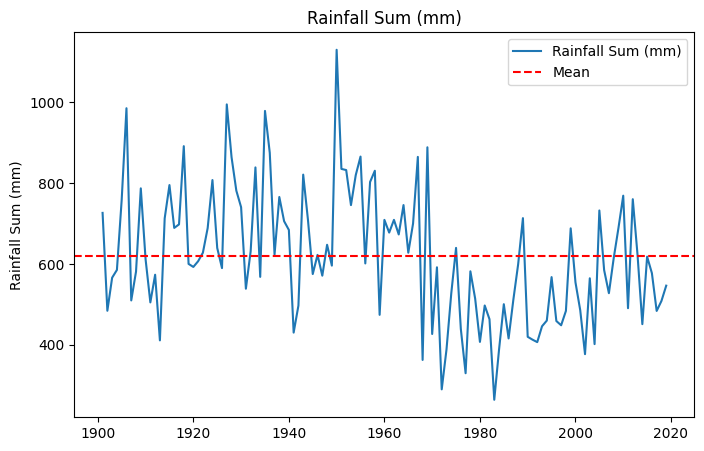

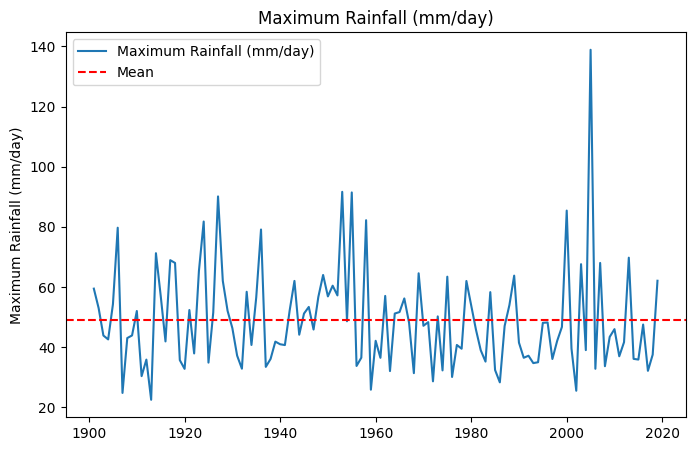

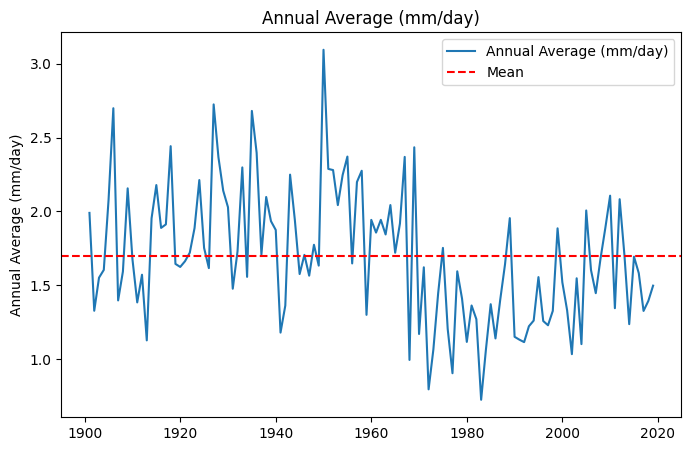

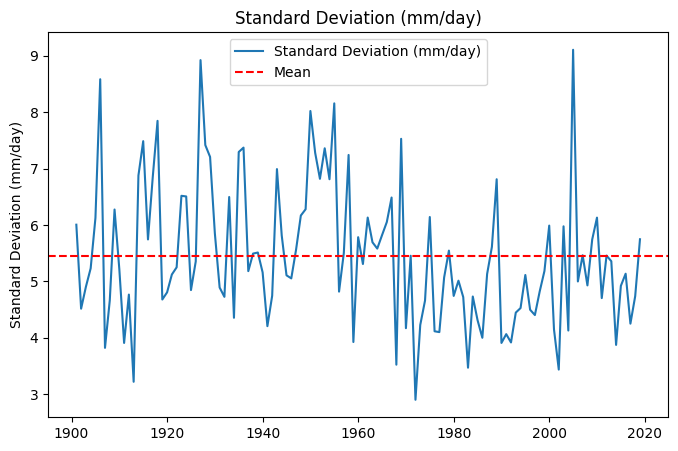

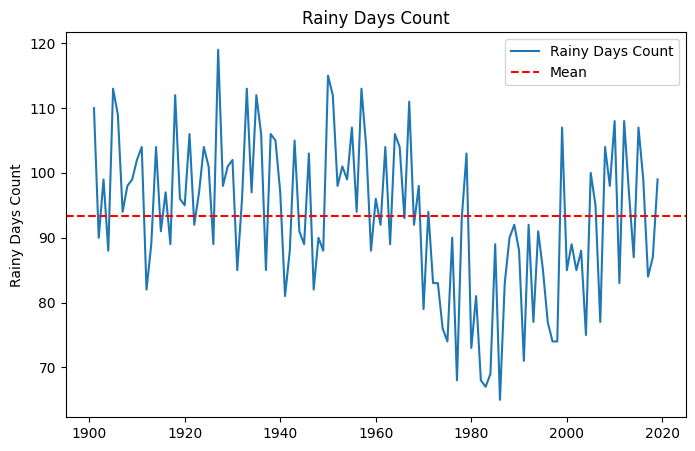

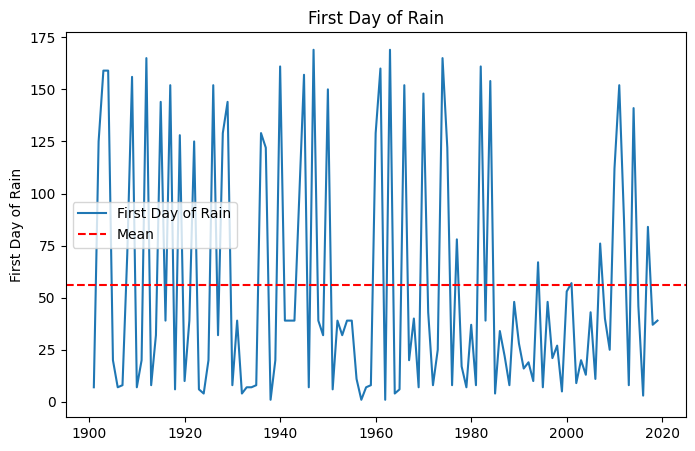

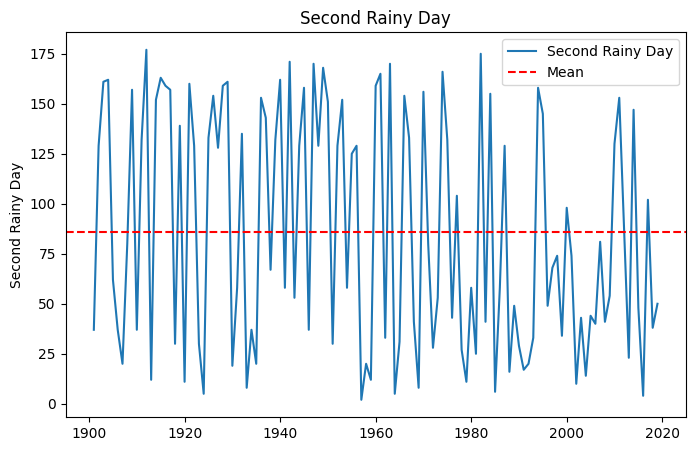

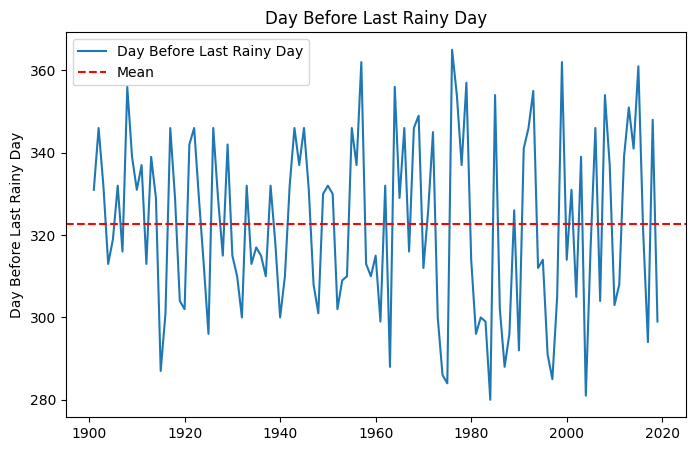

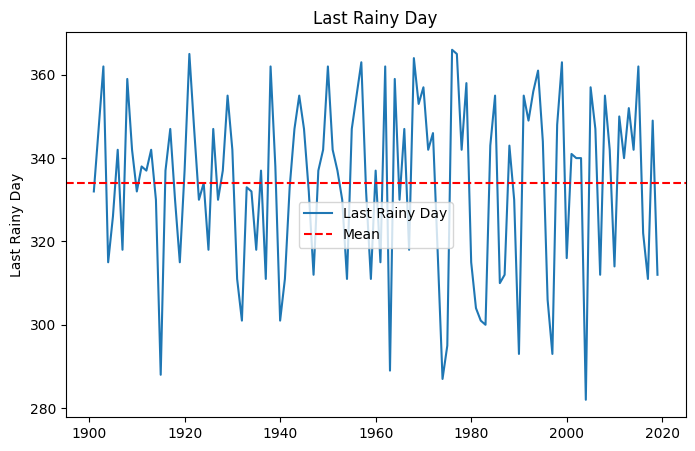

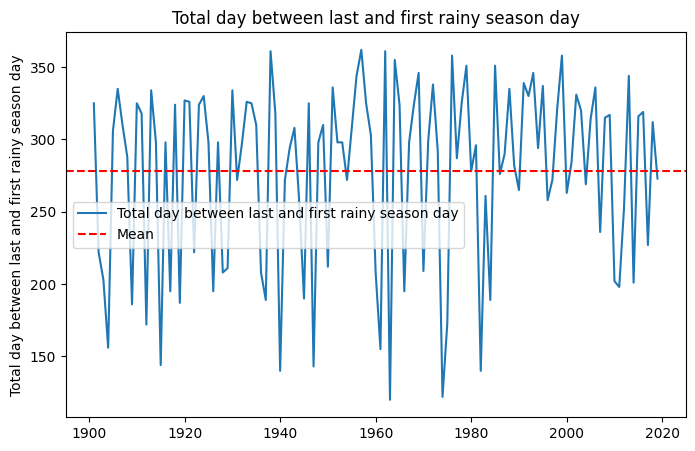

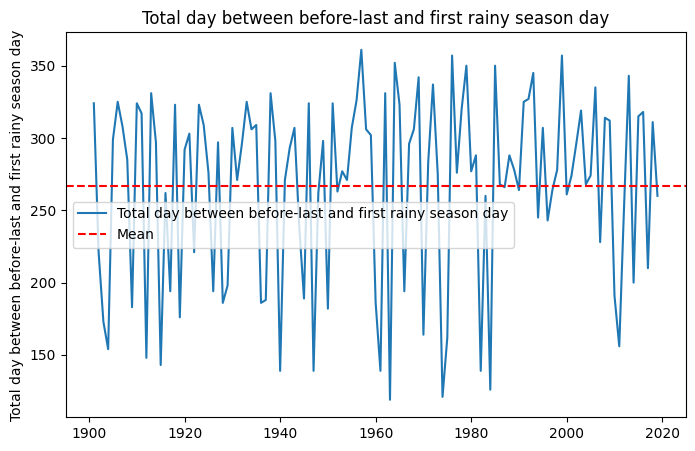

In [ ]:
# Drop the last row from 'result_df'
result_df_without_last_row = result_df.drop(result_df.index[-1])
last_row = result_df.iloc[-1:]

# Set 'Year' as the index
result_df_without_last_row = result_df_without_last_row.set_index('Year')

# Plot each column in a separate plot
for column in result_df_without_last_row.columns:
    plt.figure(figsize=(8, 5))
    plt.plot(result_df_without_last_row.index, result_df_without_last_row[column], linestyle='-', label=column)
    plt.axhline(y=last_row[column].values[0], color='red', linestyle='--', label='Mean')
    plt.ylabel(column)
    plt.title(f'{column}')
    plt.legend()
    #plt.grid(True)
    plt.show()